In [1]:
import os
from glob import glob
import numpy as np
from roman_cuts import RomanCuts
from roman_cuts.utils import WCS_ATTRS, extract_average_WCS, extract_all_WCS
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
 import sys
 def sizeof_fmt(num, suffix='B'):
     for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
         if abs(num) < 1024.0:
             return "%3.1f%s%s" % (num, unit, suffix)
         num /= 1024.0
     return "%.1f%s%s" % (num, 'Yi', suffix)

In [3]:
PATH = "/Users/jimartin/Work/ROMAN/TRExS/simulations/dryrun_01"
SSDPATH = "/Volumes/JorgeMarpa-2T/trexs/dryrun_01"

In [4]:
FILTER = "F146"
SCA = 2
FIELD = 3

ZP = {'F087': 26.29818407774948,
'F146': 27.577660642304814,
'F213': 25.85726796291789}

In [5]:
ff = sorted(glob(f"{PATH}/simulated_image_data/rimtimsim_WFI_lvl02_{FILTER}_SCA{SCA:02}_field{FIELD:02}_rampfitted_exposureno_*_sim.fits"))
# ff = sorted(glob(f"{SSDPATH}/simulated_image_data/rimtimsim_WFI_lvl02_{FILTER}_SCA{SCA:02}_field{FIELD:02}_rampfitted_exposureno_*_sim.fits"))
print(f"There are {len(ff)} frames available in {FILTER}")

There are 3298 frames available in F146


In [6]:
rcube = RomanCuts(field=FIELD, sca=SCA, filter="F146", file_list=ff[:1000])
rcube

Roman WFI Field 3 SCA 2 Filter F146 Frames 1000

In [7]:
rcube.metadata

{'MISSION': 'Roman-Sim',
 'TELESCOP': 'Roman',
 'CREATOR': 'TRExS-roman-cuts',
 'SOFTWARE': 'rimtimsim_v2.0',
 'RADESYS': 'FK5',
 'EQUINOX': 2000.0,
 'FILTER': 'F146',
 'FIELD': 3,
 'DETECTOR': 'SCA02',
 'EXPOSURE': 54.72,
 'READMODE': 'rampfitted',
 'TSTART': 2461450.4999847086,
 'TEND': 2461461.1243569716,
 'RA_CEN': None,
 'DEC_CEN': None,
 'DITHERED': None,
 'NTIMES': 1000,
 'IMGSIZE': None}

In [8]:
rcube.image_size

[4088, 4088]

In [9]:
rcube.nt, rcube.row_min_data, rcube.column_min_data, rcube.row_max_data, rcube.column_max_data

(1000, 0, 0, 4088, 4088)

In [12]:
rcube.make_cutout(rowcol=(254, 4090), size=(21, 21), dithered=False)

ValueError: Cutout exceeds image limits, reducing size.

In [13]:
rcube.make_cutout(rowcol=(254, 2925), size=(21, 21), dithered=False)

In [14]:
sizeof_fmt(sys.getsizeof(rcube.flux)), sizeof_fmt(sys.getsizeof(rcube.flux_err)), sizeof_fmt(sys.getsizeof(rcube.time))

('3.4MiB', '3.4MiB', '7.9KiB')

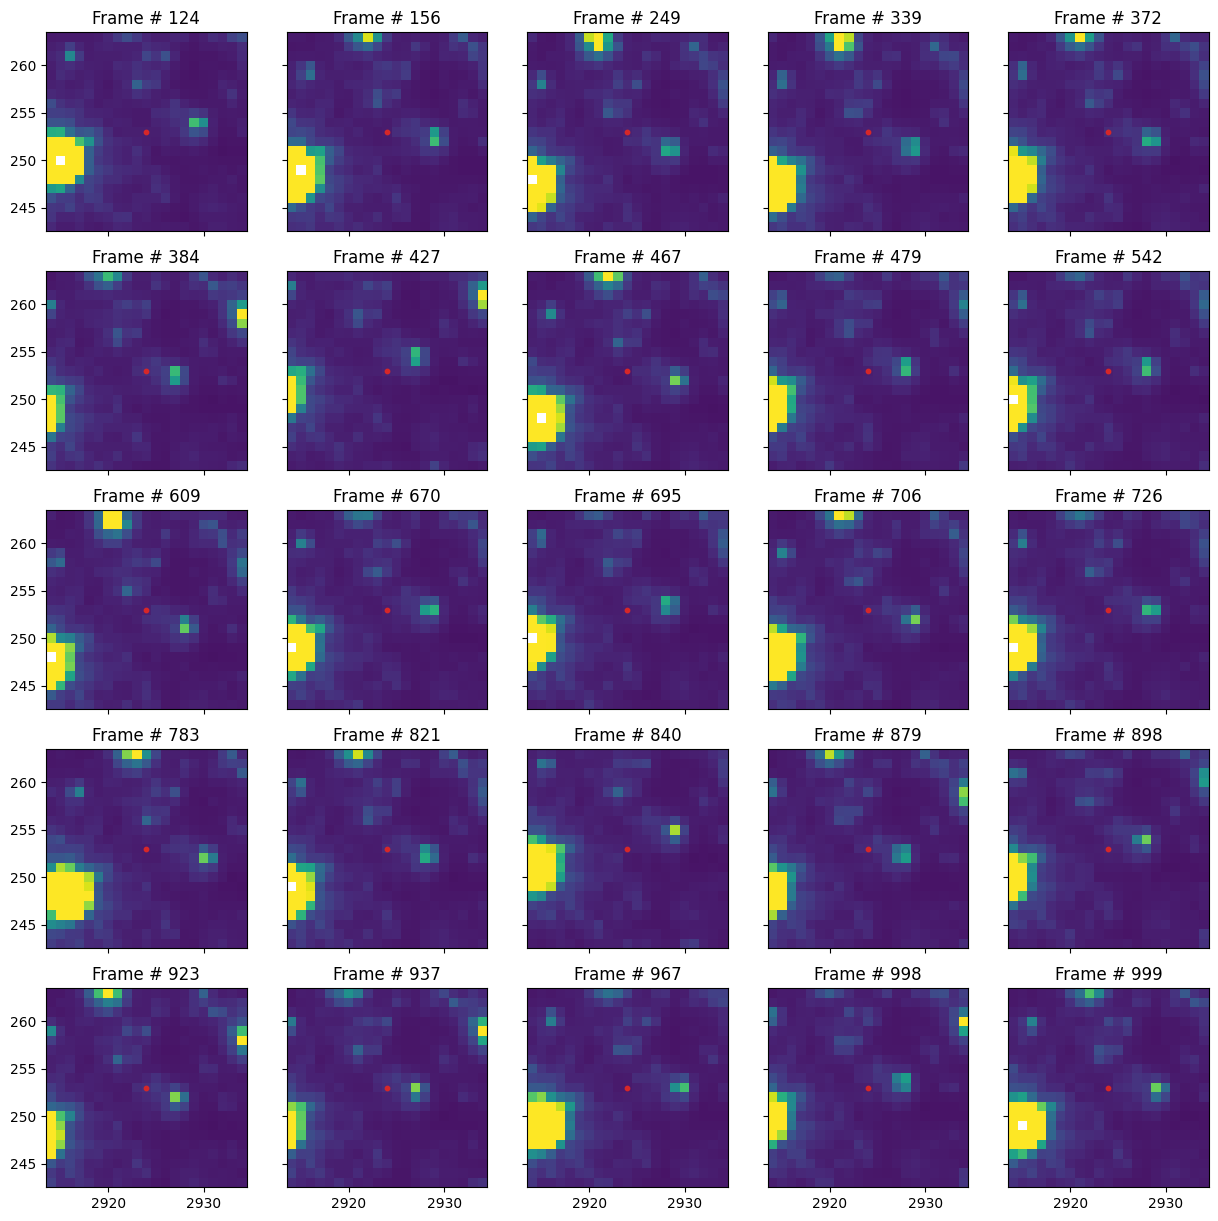

In [15]:
Ts = np.sort(np.random.choice(np.arange(rcube.nt), size=5*5, replace=False))

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column, rcube.row, rcube.flux[t], vmin=-10, vmax=500, cmap="viridis")
    axis.scatter(rcube.target_pixel[1],rcube.target_pixel[0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()

In [16]:
ra, dec = 268.490400, -29.209570
rcube.make_cutout(radec=(ra, dec), size=(21, 21), dithered=False)

Extracting cutout: 100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1721.98it/s]


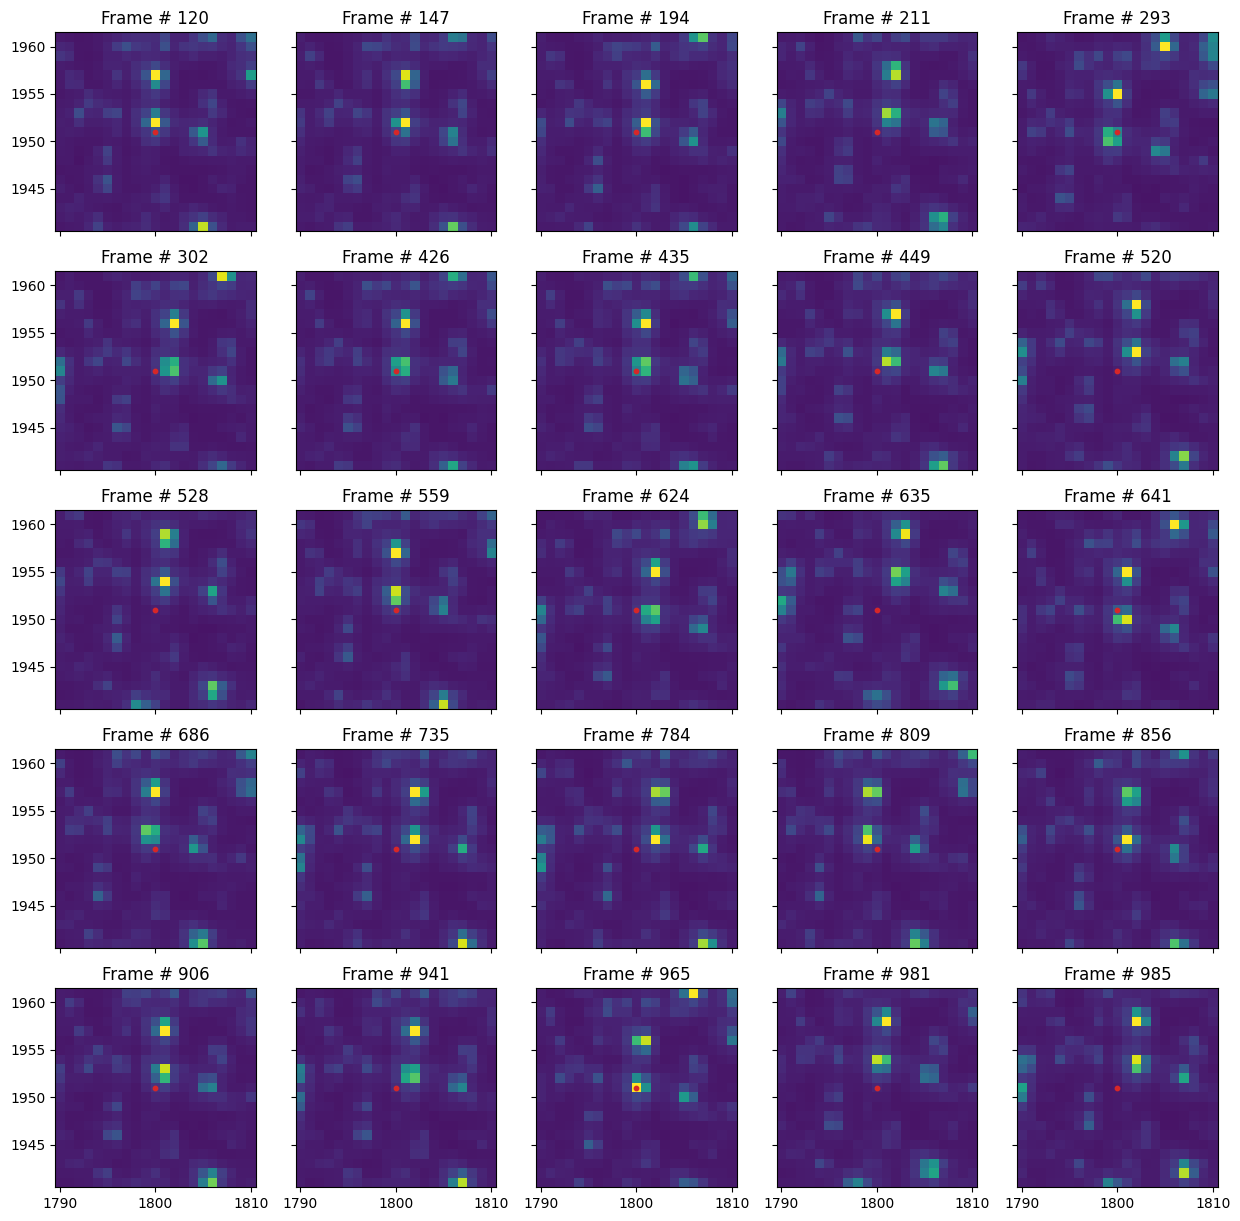

In [17]:
Ts = np.sort(np.random.choice(np.arange(rcube.nt), size=5*5, replace=False))

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column, rcube.row, rcube.flux[t], vmin=-10, vmax=500, cmap="viridis")
    axis.scatter(rcube.target_pixel[1],rcube.target_pixel[0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()

In [18]:
ra, dec = 268.490400, -29.209570
rcube.make_cutout(radec=(ra, dec), size=(21, 21), dithered=True)

Extracting cutout: 100%|█████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1421.92it/s]


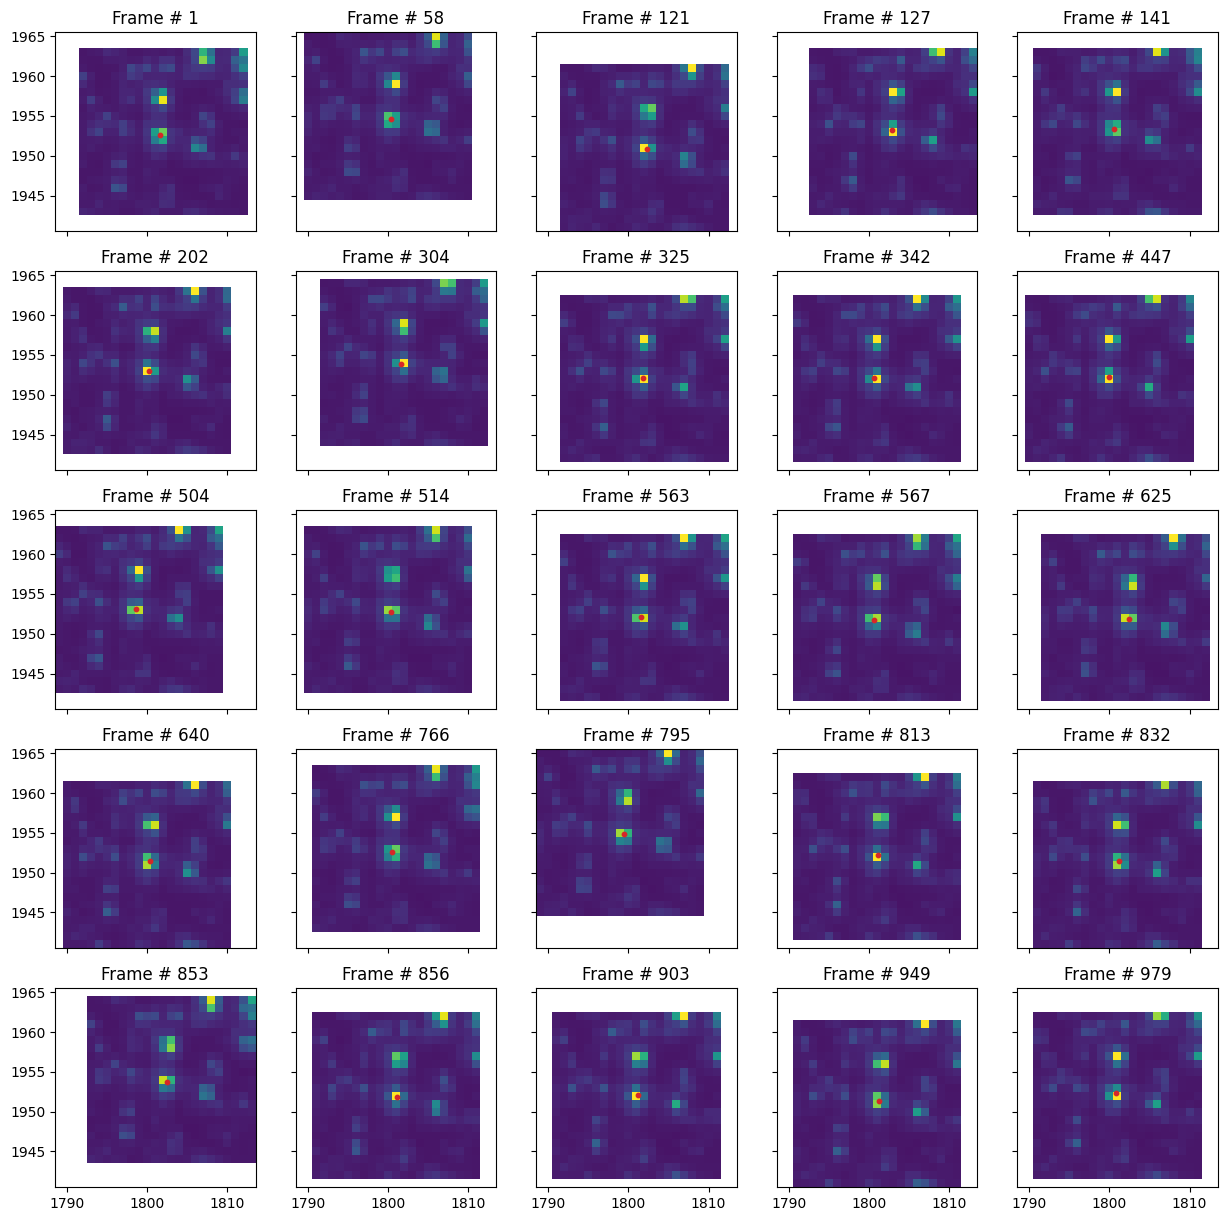

In [19]:
Ts = np.sort(np.random.choice(np.arange(rcube.nt), size=5*5, replace=False))

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column[t], rcube.row[t], rcube.flux[t], vmin=-10, vmax=500, cmap="viridis")
    axis.scatter(rcube.target_pixel[t, 1],rcube.target_pixel[t, 0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()

In [20]:
rcube.time.shape, rcube.exposureno.shape, rcube.quality.shape

((1000,), (1000,), (1000,))

In [21]:
rcube.metadata

{'MISSION': 'Roman-Sim',
 'TELESCOP': 'Roman',
 'CREATOR': 'TRExS-roman-cuts',
 'SOFTWARE': 'rimtimsim_v2.0',
 'RADESYS': 'FK5',
 'EQUINOX': 2000.0,
 'FILTER': 'F146',
 'FIELD': 3,
 'DETECTOR': 'SCA02',
 'EXPOSURE': 54.72,
 'READMODE': 'rampfitted',
 'TSTART': 2461450.4999847086,
 'TEND': 2461461.1243569716,
 'RA_CEN': 268.4904,
 'DEC_CEN': -29.20957,
 'DITHERED': True,
 'NTIMES': 1000,
 'IMGSIZE': (21, 21)}

In [17]:
rcube.save_cutout(output="./test.asdf")

In [27]:
import asdf

In [19]:
af = asdf.open("./test.asdf")
af.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 4.2.0
├─history (dict)
│ └─extensions (list)
│   ├─[0] (ExtensionMetadata) ...
│   └─[1] (ExtensionMetadata) ...
└─roman (dict)
  ├─data (dict)
  │ ├─column (int): 2914
  │ ├─exposureno (NDArrayType) ...
  │ ├─flux (NDArrayType) ...
  │ ├─flux_err (NDArrayType) ...
  │ ├─quality (NDArrayType) ...
  │ ├─row (int): 243
  │ └─time (NDArrayType) ...
  ├─meta (dict)
  │ ├─CREATOR (str): TRExS-roman-cuts
  │ └─17 not shown
  └─wcs (list) ...
Some nodes not shown.


In [99]:
# radec = (268.511213793, -29.2447394725)
radec = (268.470346, -29.208691)

In [100]:
rcube.make_cutout(radec=radec, size=(21, 21), dithered=True)

Using Ra, Dec coordinates and WCS per frame to center the cutout
Getting 3d data...
100%|█████████████████████████████████████████████████████████████████████████████████████| 3298/3298 [00:06<00:00, 525.48it/s]


In [101]:
rcube.flux.shape

(3298, 21, 21)

In [102]:
rcube.exposureno

array([    3,    11,    19, ..., 27803, 27811, 27819])

In [103]:
rcube.row

array([[1427, 1428, 1429, ..., 1445, 1446, 1447],
       [1427, 1428, 1429, ..., 1445, 1446, 1447],
       [1428, 1429, 1430, ..., 1446, 1447, 1448],
       ...,
       [1427, 1428, 1429, ..., 1445, 1446, 1447],
       [1427, 1428, 1429, ..., 1445, 1446, 1447],
       [1428, 1429, 1430, ..., 1446, 1447, 1448]])

In [104]:
rcube.flux.shape

(3298, 21, 21)

In [105]:
rcube.metadata

{'MISSION': 'Roman-Sim',
 'TELESCOP': 'Roman',
 'CREATOR': 'TRExS-roman-cuts',
 'SOFTWARE': 'rimtimsim_v2.0',
 'RADESYS': 'FK5',
 'EQUINOX': 2000.0,
 'FILTER': 'F146',
 'FIELD': 3,
 'DETECTOR': 'SCA02',
 'EXPOSURE': 54.72,
 'READMODE': 'rampfitted',
 'TSTART': 2461450.4999847086,
 'TEND': 2461485.510861832,
 'RA_CEN': 268.470346,
 'DEC_CEN': -29.208691,
 'DITHERED': True,
 'NTIMES': 3298,
 'IMGSIZE': (21, 21)}

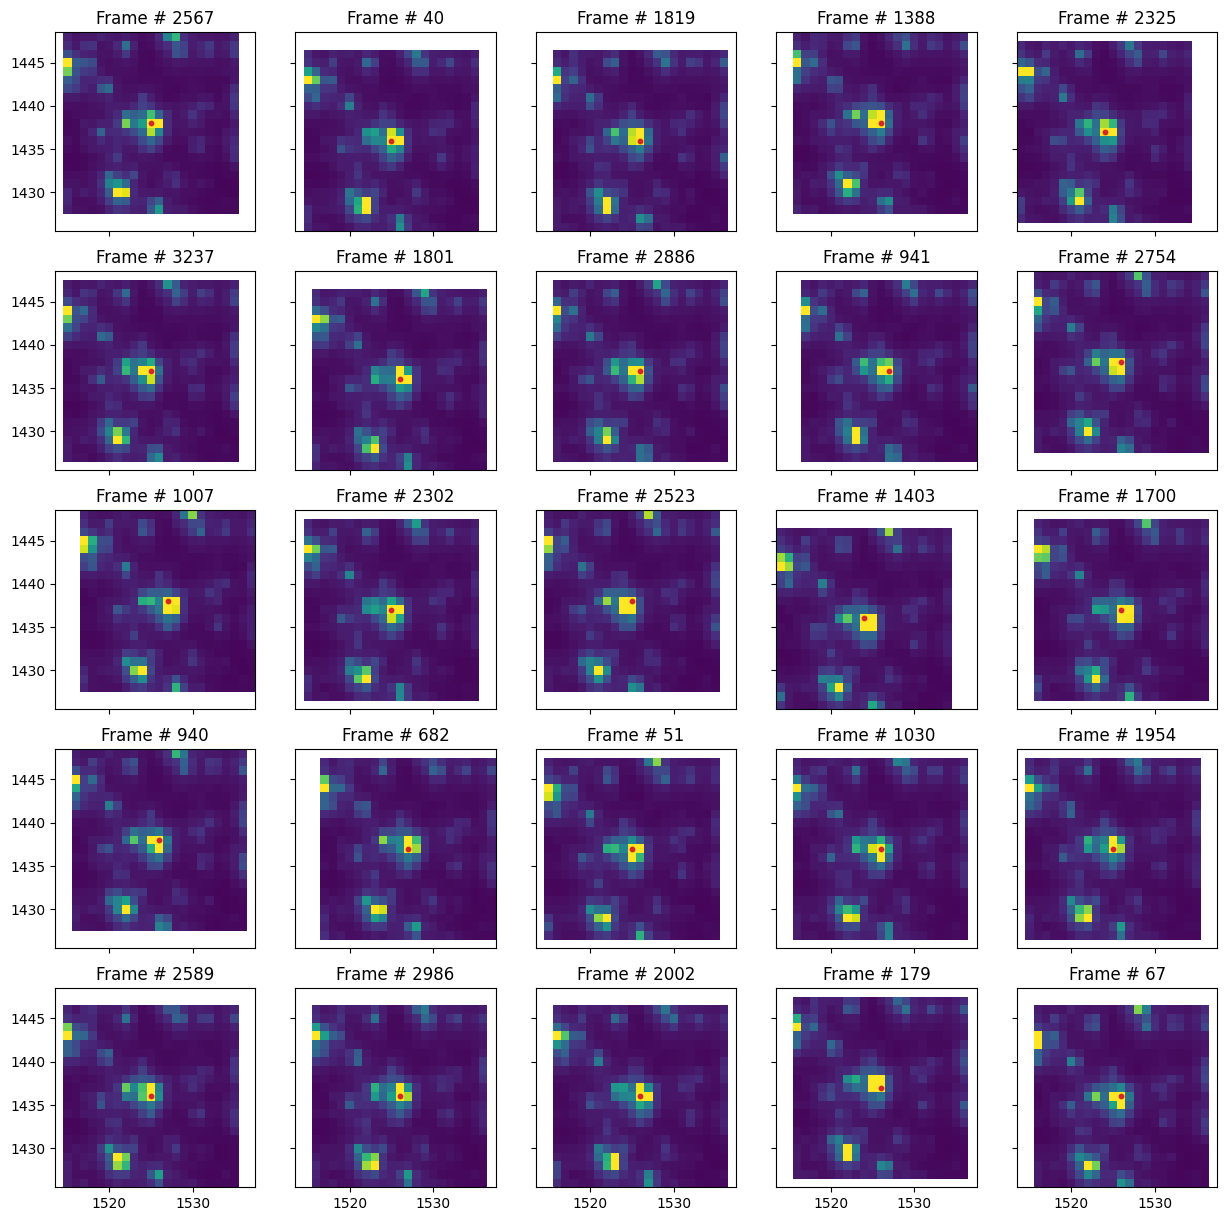

In [106]:
Ts = np.random.choice(np.arange(rcube.nt), size=5*5, replace=False)

fig, ax = plt.subplots(5,5,figsize=(15,15),sharex=True, sharey=True)
for t, axis in zip(Ts, ax.ravel()):
    axis.pcolormesh(rcube.column[t], rcube.row[t], rcube.flux[t], vmin=10, vmax=500)
    axis.scatter(rcube.target_pixel[t, 1],rcube.target_pixel[t, 0], c="tab:red", s=10)
    axis.set_title(f"Frame # {t}")
plt.show()

In [73]:
rcube.save_cutout()

Saving data to ./roman_cutout_field03_SCA02_268.5112_-29.2447_s21x21.asdf


In [74]:
af = asdf.open("./roman_cutout_field03_SCA02_268.5112_-29.2447_s21x21.asdf")
af.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 4.1.0
├─history (dict)
│ └─extensions (list)
│   ├─[0] (ExtensionMetadata) ...
│   └─[1] (ExtensionMetadata) ...
└─roman (dict)
  ├─data (dict)
  │ ├─column (NDArrayType) ...
  │ ├─exposureno (NDArrayType) ...
  │ ├─flux (NDArrayType) ...
  │ ├─flux_err (NDArrayType) ...
  │ ├─quality (NDArrayType) ...
  │ ├─row (NDArrayType) ...
  │ └─time (NDArrayType) ...
  ├─meta (dict)
  │ ├─CREATOR (str): TRExS
  │ └─17 not shown
  └─wcs (list) ...
Some nodes not shown.


In [86]:
af["roman"]["meta"]

{'CREATOR': 'TRExS',
 'DEC_CEN': -29.24473947250156,
 'DETECTOR': 'SCA02',
 'DITHERED': True,
 'EQUINOX': 2000.0,
 'EXPOSURE': 54.72,
 'FIELD': 3,
 'FILTER': 'F146',
 'IMGSIZE': [21, 21],
 'MISSION': 'Roman',
 'NTIMES': 3298,
 'RADESYS': 'FK5',
 'RA_CEN': 268.5112137932491,
 'READMODE': 'rampfitted',
 'SOFTWARE': 'rimtimsim_v2.0',
 'TELESCOP': 'Roman',
 'TEND': 2461485.510861832,
 'TSTART': 2461450.4999847086}

In [85]:
af["roman"]["data"]["exposureno"]

array([    3,    11,    19, ..., 27803, 27811, 27819])